# Agent Seed Extraction And Scene Tracking

This notebook runs full-video scene splitting, analyzes each scene for object seeds, sends those seeds to the SAM3 visual inference server, and renders scene-local tracking overlays.

In [1]:
import os
os.environ["V2A_INSPECT_VIDEO_ENCODE_USE_NVENC"] = "false"

In [2]:
from pathlib import Path
import dotenv

dotenv.load_dotenv(dotenv.find_dotenv())

import httpx

from v2a_inspect.client import SAM3Client, VideoClient
from v2a_inspect.preprocessing import (
    analyze_initial_scenes,
    preprocess_video,
    sam3_tracking_video_path,
    track_initial_scenes_object_seeds,
)
from v2a_inspect.visualization import (
    display_image,
    display_video,
    render_keyframe_grid,
    render_scene_timeline,
    render_tracking_video,
    summarize_scenes,
    summarize_tracks,
)

## Config

By default, this runs every detected scene. Set `SELECTED_SCENE_INDEXES` or `MAX_SCENES_TO_PROCESS` to limit cost while tuning prompts and server memory use.

In [3]:
SERVER_URL = "http://localhost:8080"
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_VIDEO_PATH = (PROJECT_ROOT / "/home/gwpark0741/NC/v2a_inspect/videos/13.mp4").resolve()
OUTPUT_DIR = PROJECT_ROOT / "demo" / "outputs" / "agent_seed_tracking"
WORK_DIR = OUTPUT_DIR / "work"
SELECTED_SCENE_INDEXES = None
MAX_SCENES_TO_PROCESS = None
MAX_KEYFRAMES_PER_SCENE = 8

RUN_LLM_ANALYSIS = True
RUN_SERVER_REQUESTS = True
RUN_TRACKING = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)
RAW_VIDEO_PATH

PosixPath('/home/gwpark0741/NC/v2a_inspect/videos/13.mp4')

## Local Preprocessing

This stays local: normalize the raw video, create the 360p SAM3 tracking variant, detect initial scenes, and extract representative keyframes. NVENC is used by default for H.264 encoding.

In [4]:
video_asset = preprocess_video(
    RAW_VIDEO_PATH,
    WORK_DIR,
    max_keyframes_per_scene=MAX_KEYFRAMES_PER_SCENE,
)
scene_indexes = (
    list(range(len(video_asset.initial_scenes)))
    if SELECTED_SCENE_INDEXES is None
    else list(SELECTED_SCENE_INDEXES)
)
if MAX_SCENES_TO_PROCESS is not None:
    scene_indexes = scene_indexes[:MAX_SCENES_TO_PROCESS]

{
    "raw_path": str(RAW_VIDEO_PATH),
    "prepared_path": str(video_asset.source_path),
    "sam3_tracking_path": None
    if video_asset.sam3_tracking_path is None
    else str(video_asset.sam3_tracking_path),
    "frame_count": video_asset.frame_count,
    "duration_sec": video_asset.duration_sec,
    "scene_count": len(video_asset.initial_scenes),
    "processing_scene_count": len(scene_indexes),
    "scene_indexes": scene_indexes,
}

{'raw_path': '/home/gwpark0741/NC/v2a_inspect/videos/13.mp4',
 'prepared_path': '/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/work/13.prepared.mp4',
 'sam3_tracking_path': '/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/work/13.sam3.mp4',
 'frame_count': 514,
 'duration_sec': 17.133333333333333,
 'scene_count': 11,
 'processing_scene_count': 11,
 'scene_indexes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

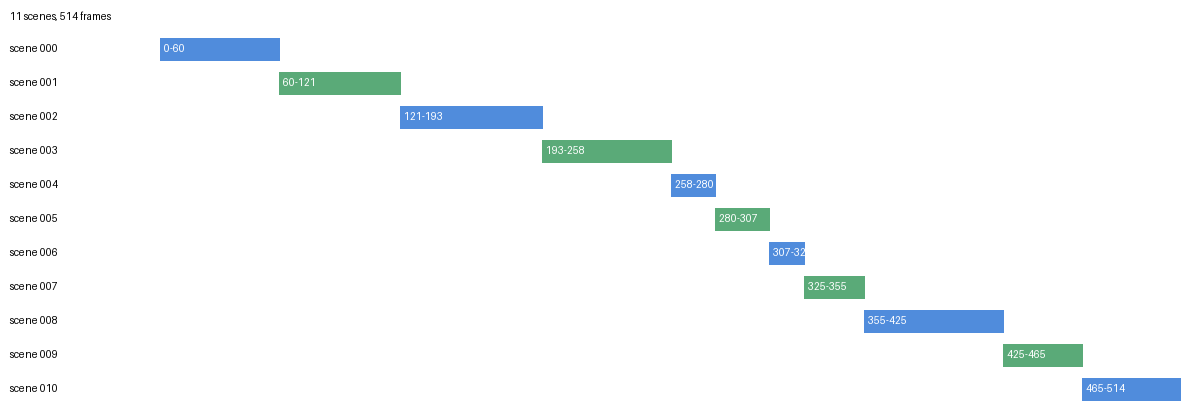

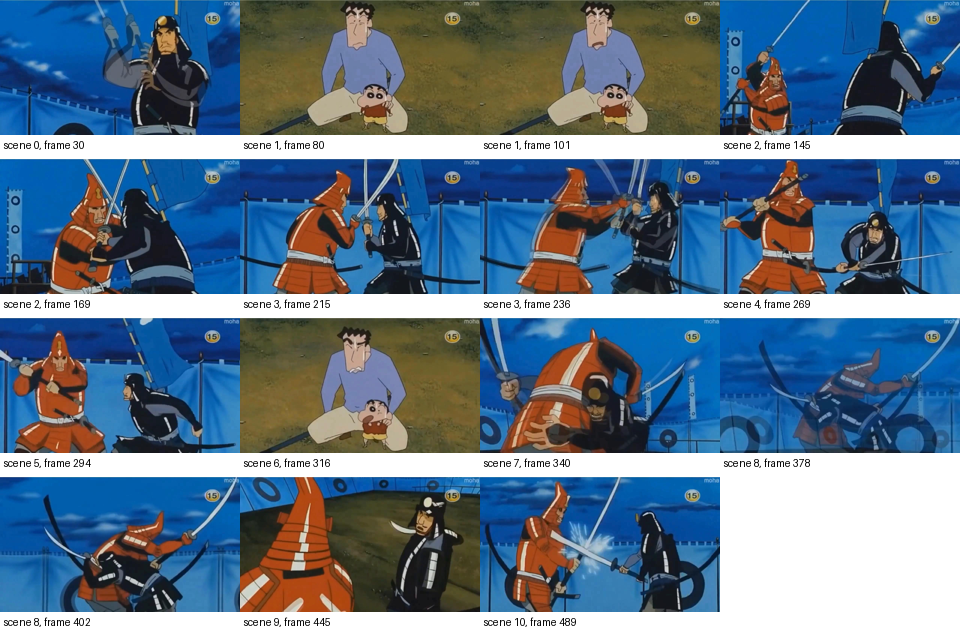

[{'scene_index': 0,
  'start_frame_index': 0,
  'end_frame_index': 60,
  'frame_count': 60,
  'duration_sec': 2.0,
  'keyframe_count': 1,
  'track_count': 0},
 {'scene_index': 1,
  'start_frame_index': 60,
  'end_frame_index': 121,
  'frame_count': 61,
  'duration_sec': 2.033333333333333,
  'keyframe_count': 2,
  'track_count': 0},
 {'scene_index': 2,
  'start_frame_index': 121,
  'end_frame_index': 193,
  'frame_count': 72,
  'duration_sec': 2.4,
  'keyframe_count': 2,
  'track_count': 0},
 {'scene_index': 3,
  'start_frame_index': 193,
  'end_frame_index': 258,
  'frame_count': 65,
  'duration_sec': 2.1666666666666665,
  'keyframe_count': 2,
  'track_count': 0},
 {'scene_index': 4,
  'start_frame_index': 258,
  'end_frame_index': 280,
  'frame_count': 22,
  'duration_sec': 0.7333333333333333,
  'keyframe_count': 1,
  'track_count': 0},
 {'scene_index': 5,
  'start_frame_index': 280,
  'end_frame_index': 307,
  'frame_count': 27,
  'duration_sec': 0.9,
  'keyframe_count': 1,
  'track_

In [5]:
display_image(render_scene_timeline(video_asset))
display_image(render_keyframe_grid([video_asset.initial_scenes[index] for index in scene_indexes]))
summarize_scenes(video_asset)

## Seed Extraction

The local LLM analyzes each configured scene and produces `ObjectSeed`s. These seeds are later converted to SAM3 text prompts.

In [6]:
if RUN_LLM_ANALYSIS:
    scenes_to_analyze = [video_asset.initial_scenes[index] for index in scene_indexes]
    analyzed_scenes = analyze_initial_scenes(scenes_to_analyze)
    updated_scenes = list(video_asset.initial_scenes)
    for scene_index, analyzed_scene in zip(scene_indexes, analyzed_scenes, strict=True):
        updated_scenes[scene_index] = analyzed_scene
    video_asset = video_asset.model_copy(update={"initial_scenes": updated_scenes})
else:
    print("Skipped. Set RUN_LLM_ANALYSIS = True to extract object seeds.")

Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Q

In [7]:
seed_rows = []
for scene_index in scene_indexes:
    scene = video_asset.initial_scenes[scene_index]
    if scene.initial_analysis is None:
        continue
    for object_seed in scene.initial_analysis.object_seeds:
        seed_rows.append(
            {
                "scene_index": scene_index,
                "label": object_seed.label,
                "tracking_prompt": object_seed.tracking_prompt,
                "notes": object_seed.notes,
            }
        )
seed_rows

[{'scene_index': 0,
  'label': 'samurai',
  'tracking_prompt': 'samurai in black armor',
  'notes': 'The main character in the scene.'},
 {'scene_index': 0,
  'label': 'helmet',
  'tracking_prompt': 'black helmet with gold emblem',
  'notes': 'The helmet worn by the samurai.'},
 {'scene_index': 0,
  'label': 'sword hilt',
  'tracking_prompt': 'sword hilt at waist',
  'notes': "The hilt of the sword visible at the samurai's waist."},
 {'scene_index': 1,
  'label': 'man',
  'tracking_prompt': 'man in blue shirt',
  'notes': 'The tall crouching man in the blue long-sleeve shirt.'},
 {'scene_index': 1,
  'label': 'boy',
  'tracking_prompt': 'boy in red shirt',
  'notes': 'The small boy standing in front of the man.'},
 {'scene_index': 2,
  'label': 'red warrior',
  'tracking_prompt': 'warrior in red armor',
  'notes': 'The samurai warrior on the left wearing red armor and helmet.'},
 {'scene_index': 2,
  'label': 'black warrior',
  'tracking_prompt': 'warrior in black armor',
  'notes': 'T

## Upload And Track

The server is visual-inference-only. It receives the generated SAM3 tracking video plus scene-bounded SAM3 requests for the configured scenes.

In [8]:
if RUN_SERVER_REQUESTS:
    async with httpx.AsyncClient(base_url=SERVER_URL, timeout=30.0) as http_client:
        health = await http_client.get("/healthz")
        health.raise_for_status()
        print(health.json())
else:
    print("Skipped. Set RUN_SERVER_REQUESTS = True to call the server.")

{'status': 'ok'}


In [9]:
tracking_video_path = sam3_tracking_video_path(video_asset)
video_id = None
if RUN_SERVER_REQUESTS:
    async with VideoClient(SERVER_URL) as video_client:
        upload_response = await video_client.upload(str(tracking_video_path))
        video_id = upload_response.video_id
{"video_id": video_id, "uploaded_path": str(tracking_video_path)}

{'video_id': 'd06b358c-594d-4b62-844a-a1780a5dd9a3',
 'uploaded_path': '/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/work/13.sam3.mp4'}

In [10]:
if RUN_SERVER_REQUESTS and RUN_TRACKING and video_id is not None:
    async with SAM3Client(SERVER_URL, timeout=1800.0) as sam_client:
        video_asset = await track_initial_scenes_object_seeds(
            video_asset,
            video_id=video_id,
            sam_client=sam_client,
            scene_indexes=scene_indexes,
        )
else:
    print("Skipped. Enable server requests and tracking after seeds are available.")

Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused
Media upload error: Failed to upload media due to unexpected error. Queue item marked as done. Error: [Errno 111] Connection refused


## Visualize Results

In [11]:
for scene_index in scene_indexes:
    scene = video_asset.initial_scenes[scene_index]
    print({
        "scene_index": scene_index,
        "start_frame_index": scene.start_frame_index,
        "end_frame_index": scene.end_frame_index,
        "seed_count": 0 if scene.initial_analysis is None else len(scene.initial_analysis.object_seeds),
        "track_count": len(scene.scene_tracks),
    })
    if scene.scene_tracks:
        overlay_path = OUTPUT_DIR / f"scene_{scene_index:03d}_seed_tracks.mp4"
        render_tracking_video(
            video_asset.source_path,
            scene.scene_tracks,
            overlay_path,
            start_frame_index=scene.start_frame_index,
            end_frame_index=scene.end_frame_index,
        )
        display_video(overlay_path)
        print(summarize_tracks(scene.scene_tracks))

{'scene_index': 0, 'start_frame_index': 0, 'end_frame_index': 60, 'seed_count': 3, 'track_count': 1}


[{'track_id': '320548dc-3f4b-408f-b97b-dccb62b0c3c8', 'point_count': 60, 'start_frame_index': 0, 'end_frame_index': 60, 'min_confidence': 0.8241757750511169, 'mean_confidence': 0.8241757750511169, 'mask_count': 60}]
{'scene_index': 1, 'start_frame_index': 60, 'end_frame_index': 121, 'seed_count': 2, 'track_count': 2}


[{'track_id': '499894b6-c382-44fa-8dbf-4f33f2bdbb25', 'point_count': 60, 'start_frame_index': 61, 'end_frame_index': 121, 'min_confidence': 0.8672199249267578, 'mean_confidence': 0.8672199249267578, 'mask_count': 60}, {'track_id': '833f8fcc-44b6-4e9c-9e1d-c3c192af618f', 'point_count': 60, 'start_frame_index': 61, 'end_frame_index': 121, 'min_confidence': 0.7142857313156128, 'mean_confidence': 0.7142857313156128, 'mask_count': 60}]
{'scene_index': 2, 'start_frame_index': 121, 'end_frame_index': 193, 'seed_count': 3, 'track_count': 1}


[{'track_id': '20062869-c2ba-44bc-a54e-8b5d9f6555eb', 'point_count': 72, 'start_frame_index': 121, 'end_frame_index': 193, 'min_confidence': 0.7104072570800781, 'mean_confidence': 0.7104072570800781, 'mask_count': 72}]
{'scene_index': 3, 'start_frame_index': 193, 'end_frame_index': 258, 'seed_count': 4, 'track_count': 2}


[{'track_id': '3cd63c13-4e8a-48ac-97b6-11e561c85fb8', 'point_count': 31, 'start_frame_index': 225, 'end_frame_index': 258, 'min_confidence': 0.6800000071525574, 'mean_confidence': 0.6800000071525574, 'mask_count': 31}, {'track_id': 'ccd6043e-8c69-40e3-bb19-70afa87d1039', 'point_count': 28, 'start_frame_index': 193, 'end_frame_index': 221, 'min_confidence': 0.8048780560493469, 'mean_confidence': 0.8048780560493469, 'mask_count': 28}]
{'scene_index': 4, 'start_frame_index': 258, 'end_frame_index': 280, 'seed_count': 4, 'track_count': 4}


[{'track_id': 'fa59b953-c778-430e-ab3d-18eae817cdbe', 'point_count': 22, 'start_frame_index': 258, 'end_frame_index': 280, 'min_confidence': 0.7299578189849854, 'mean_confidence': 0.7299578189849854, 'mask_count': 22}, {'track_id': 'b1562b3d-afc9-4bfc-aa0c-6996b4820334', 'point_count': 17, 'start_frame_index': 258, 'end_frame_index': 280, 'min_confidence': 0.6521739363670349, 'mean_confidence': 0.6521739363670349, 'mask_count': 17}, {'track_id': 'a86b116b-4d03-445e-920e-679b551e94cf', 'point_count': 3, 'start_frame_index': 277, 'end_frame_index': 280, 'min_confidence': 0.6640419960021973, 'mean_confidence': 0.6640419960021973, 'mask_count': 3}, {'track_id': 'b087d595-0ba2-4941-a436-b366c8f08c54', 'point_count': 4, 'start_frame_index': 258, 'end_frame_index': 262, 'min_confidence': 0.7500000596046448, 'mean_confidence': 0.7500000596046448, 'mask_count': 4}]
{'scene_index': 5, 'start_frame_index': 280, 'end_frame_index': 307, 'seed_count': 3, 'track_count': 3}


[{'track_id': 'ace2fe68-7478-4106-aada-636569e84805', 'point_count': 27, 'start_frame_index': 280, 'end_frame_index': 307, 'min_confidence': 0.9649122953414917, 'mean_confidence': 0.9649122953414917, 'mask_count': 27}, {'track_id': 'c4638e96-2560-4f75-954a-9d69eba6ce46', 'point_count': 27, 'start_frame_index': 280, 'end_frame_index': 307, 'min_confidence': 0.859649121761322, 'mean_confidence': 0.859649121761322, 'mask_count': 27}, {'track_id': 'd8ffd9f5-ccca-4f2d-a631-31b081bc397c', 'point_count': 25, 'start_frame_index': 280, 'end_frame_index': 307, 'min_confidence': 0.6908212304115295, 'mean_confidence': 0.6908212304115295, 'mask_count': 25}]
{'scene_index': 6, 'start_frame_index': 307, 'end_frame_index': 325, 'seed_count': 2, 'track_count': 1}


[{'track_id': '0fe360e3-9c9e-4555-92fe-322df7e49294', 'point_count': 18, 'start_frame_index': 307, 'end_frame_index': 325, 'min_confidence': 0.7264957427978516, 'mean_confidence': 0.7264957427978516, 'mask_count': 18}]
{'scene_index': 7, 'start_frame_index': 325, 'end_frame_index': 355, 'seed_count': 3, 'track_count': 3}


[{'track_id': '43f96ce5-75fd-4c86-93d8-24488d7b4ff2', 'point_count': 30, 'start_frame_index': 325, 'end_frame_index': 355, 'min_confidence': 0.8476190567016602, 'mean_confidence': 0.8476190567016602, 'mask_count': 30}, {'track_id': '8711176e-08ed-43ea-ab78-b5a45b61d688', 'point_count': 26, 'start_frame_index': 325, 'end_frame_index': 355, 'min_confidence': 0.7538461089134216, 'mean_confidence': 0.7538461089134216, 'mask_count': 26}, {'track_id': '330be67c-29c1-4db9-9506-5b8f3389c3f3', 'point_count': 30, 'start_frame_index': 325, 'end_frame_index': 355, 'min_confidence': 0.7500000596046448, 'mean_confidence': 0.7500000596046448, 'mask_count': 30}]
{'scene_index': 8, 'start_frame_index': 355, 'end_frame_index': 425, 'seed_count': 2, 'track_count': 0}
{'scene_index': 9, 'start_frame_index': 425, 'end_frame_index': 465, 'seed_count': 2, 'track_count': 3}


[{'track_id': 'dbea7790-f5f6-47ed-81b6-942c6e07e919', 'point_count': 40, 'start_frame_index': 425, 'end_frame_index': 465, 'min_confidence': 0.96875, 'mean_confidence': 0.96875, 'mask_count': 40}, {'track_id': 'ef626ed8-3eb1-46dc-856f-88cf621aefcc', 'point_count': 40, 'start_frame_index': 425, 'end_frame_index': 465, 'min_confidence': 0.9375000596046448, 'mean_confidence': 0.9375000596046448, 'mask_count': 40}, {'track_id': '4e7bcf1f-5135-43de-84fb-ac5d66554639', 'point_count': 40, 'start_frame_index': 425, 'end_frame_index': 465, 'min_confidence': 0.921951174736023, 'mean_confidence': 0.921951174736023, 'mask_count': 40}]
{'scene_index': 10, 'start_frame_index': 465, 'end_frame_index': 514, 'seed_count': 2, 'track_count': 0}


## Save Artifact

In [12]:
asset_path = OUTPUT_DIR / "video_asset.json"
tmp_asset_path = asset_path.with_suffix(".tmp.json")
tmp_asset_path.write_text(
    video_asset.model_dump_json(indent=2, exclude_computed_fields=True),
    encoding="utf-8",
)
_ = type(video_asset).model_validate_json(tmp_asset_path.read_text(encoding="utf-8"))
tmp_asset_path.replace(asset_path)
asset_path



PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/video_asset.json')